# Store Intelligence Pipeline

Retail stores sit on hours of CCTV footage that mostly just collects dust. This project turns five raw camera feeds from a single store session into a structured event stream — entries, exits, zone dwell times, queue depth at billing, staff separation — and then pulls actionable metrics out of it.

The five cameras cover different parts of the store: two product floor feeds, one entrance, one billing counter, one back-of-store staff area. Each needs slightly different detection logic, but they all write to the same JSONL event schema so the analytics layer stays uniform.

Running on Colab because my laptop only has Intel Iris integrated graphics. YOLOv8 on CPU would take 3–4 hours per clip; on the T4 it's around 8 minutes.

**Pipeline overview:**
1. Environment setup — GPU check, installs, Drive mount
2. Extract and inspect footage
3. Camera config and detection thresholds
4. Event schema (Pydantic models)
5. Re-ID tracker — keeps visitor identity stable across re-entries
6. Staff detection via HSV torso colour
7. Per-camera detection loop → JSONL event stream
8. Analytics and automated recommendations


## 1. Environment Setup

First thing on a fresh Colab session: confirm the GPU is actually assigned before spending time on installs. T4 is what we want. If this shows CPU, go to *Runtime → Change runtime type* before continuing.


In [1]:
# Confirm GPU assignment — T4 is what we're after
!nvidia-smi

# Core installs:
#   ultralytics  — YOLOv8 + ByteTrack tracker bundled
#   opencv-python-headless — Colab-safe, no display dependencies
#   pydantic — strict typing for the event schema, catches field errors early
!pip install ultralytics opencv-python-headless pydantic -q

# Mount Drive so footage loads without re-uploading and events persist across
# Colab disconnects (sessions reset after ~90 min of inactivity)
from google.colab import drive
drive.mount('/content/drive')


Wed Apr 22 15:42:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Load Footage

Footage lives as a zip on Drive rather than being re-uploaded each session. Colab's local `/content/` storage resets on reconnect, so loading from Drive is the safe pattern here. The `raise` on missing file is intentional — nothing downstream will work without the clips and a silent failure wastes GPU time.


In [2]:
import zipfile
import os

ZIP_PATH    = '/content/drive/MyDrive/cctv.zip'
EXTRACT_DIR = '/content/dataset'

if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print(f"Extracted: {os.listdir(EXTRACT_DIR)}")
else:
    # Hard stop — nothing below runs without the footage
    raise FileNotFoundError(
        "cctv.zip not found in Drive root. "
        "Upload it to Google Drive and re-run."
    )


Extracted: ['CAM 5.mp4', 'CAM 1.mp4', 'CAM 4.mp4', 'CAM 2.mp4', 'CAM 3.mp4']


## 3. Understand the Camera Layout

The clips arrived with no labels — just CAM 1 through CAM 5. Before writing any detection logic I pulled the first frame from each one to figure out what each camera actually covers. This matters a lot: entry/exit logic only applies to the entrance camera, queue depth only to billing, and the back-of-store feed should be excluded from customer metrics entirely.

After checking the frames:
- **CAM 1, CAM 2** — product shelves (zones A and B)
- **CAM 3** — main entrance, door threshold clearly visible
- **CAM 4** — back of store / staff area (customers shouldn't appear here)
- **CAM 5** — billing counter



📹 CAM 1.mp4


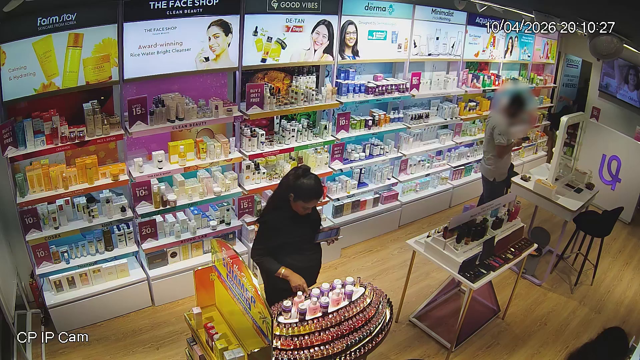


📹 CAM 2.mp4


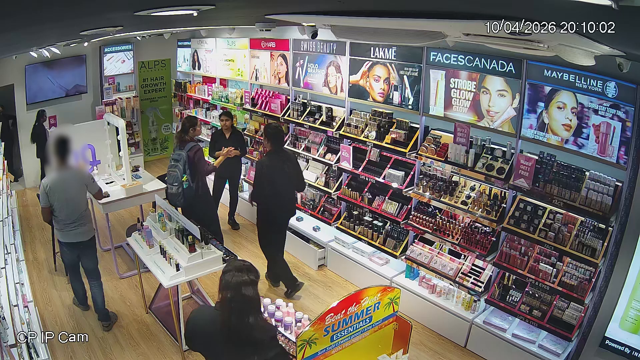


📹 CAM 3.mp4


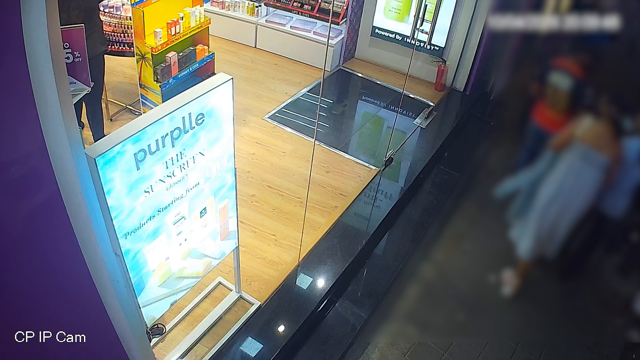


📹 CAM 4.mp4


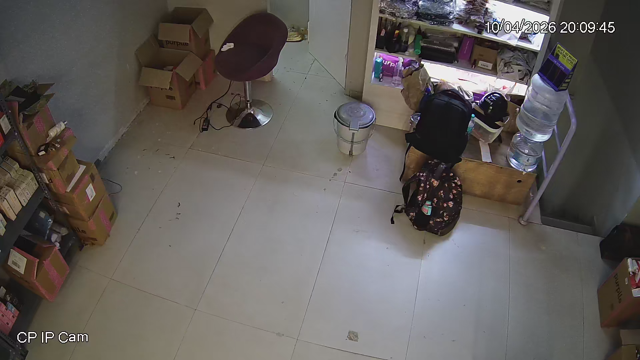


📹 CAM 5.mp4


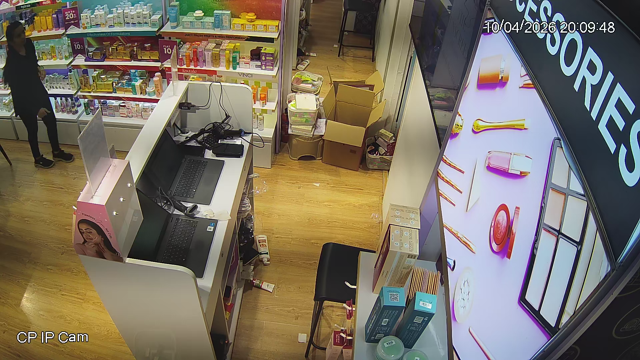

In [3]:
import cv2
from IPython.display import display
import PIL.Image

CLIPS = [
    '/content/dataset/CAM 1.mp4',
    '/content/dataset/CAM 2.mp4',
    '/content/dataset/CAM 3.mp4',
    '/content/dataset/CAM 4.mp4',
    '/content/dataset/CAM 5.mp4',
]

for clip_path in CLIPS:
    cap = cv2.VideoCapture(clip_path)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f'Could not read: {clip_path}')
        continue

    # OpenCV reads BGR; PIL expects RGB — convert before displaying
    img = PIL.Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    img.thumbnail((640, 360))
    print(f'\n📹 {os.path.basename(clip_path)}')
    display(img)


## 4. Imports and Configuration

All imports in one place — makes it easy to see dependencies at a glance and avoids the common notebook trap where imports scattered across cells break when you run them out of order.

The config block maps physical camera filenames to logical IDs (so detection logic never hardcodes filenames) and sets every tunable threshold. Anything you'd need to adjust for a different store lives here.

One thing worth calling out: `ENTRY_LINE_RATIO = 0.50`. I checked the first frame of CAM 3 above and the door threshold sits at roughly the vertical midpoint of the frame. On a different mounting angle you'd tweak this — the frame preview cell above is specifically there to help with that.


In [4]:
# All remaining imports — cv2, os already loaded above
import json
import glob
import hashlib
import uuid
from datetime import datetime, timezone, timedelta
from typing import Optional
from pydantic import BaseModel, Field
from dataclasses import dataclass, field as dc_field
from ultralytics import YOLO
import numpy as np

CLIPS_DIR   = '/content/dataset'  # same as EXTRACT_DIR above
STORE_ID    = 'STORE_BLR_002'
CLIP_START  = '2026-03-03T14:00:00Z'
OUTPUT_FILE = '/content/drive/MyDrive/events.jsonl'

CAM_MAP = {
    'CAM 1.mp4': 'CAM_FLOOR_01',      # product shelves A
    'CAM 2.mp4': 'CAM_FLOOR_02',      # product shelves B
    'CAM 3.mp4': 'CAM_ENTRY_01',      # main entrance
    'CAM 4.mp4': 'CAM_BACKSTORE_01',  # staff/storage area
    'CAM 5.mp4': 'CAM_BILLING_01',    # billing counter
}

ZONE_MAP = {
    'CAM_FLOOR_01':     'PRODUCT_ZONE_A',
    'CAM_FLOOR_02':     'PRODUCT_ZONE_B',
    'CAM_BILLING_01':   'BILLING',
    'CAM_BACKSTORE_01': 'BACKSTORE',
    'CAM_ENTRY_01':     None,
}

# Tunable detection thresholds — adjust these for different store layouts
DWELL_INTERVAL_SEC   = 30      # emit a ZONE_DWELL heartbeat every 30s while someone stays
LOITER_THRESHOLD_SEC = 180     # flag as loitering after 3 minutes
CROWD_THRESHOLD      = 6       # more than 6 people in frame = crowd alert
ENTRY_LINE_RATIO     = 0.50    # virtual entry line on CAM 3 — check frame preview above to calibrate
CONF_THRESHOLD       = 0.35    # detections below this confidence are ignored

print('✅ Config ready')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Config ready


## 5. Event Schema

Every detection gets serialised as a `StoreEvent`. Having a consistent schema from the start is worth the upfront effort — the analytics layer, any downstream API, or a BI tool can all consume the same JSONL without transformation.

A few design decisions worth flagging:
- **`visitor_id` is not the same as YOLO's `track_id`**. ByteTrack resets track IDs   whenever a person leaves frame. `visitor_id` stays stable across re-entries,   maintained by the Re-ID tracker built in the next section.
- **`dwell_ms` on `ZONE_EXIT`** is the total elapsed time in that zone for that   visit — not a snapshot of a single frame.
- **`is_staff`** is derived from two signals: black uniform OR appearance on the   back-of-store camera. Once set to `True` for a track, it stays `True`.
- **`metadata.queue_depth`** is only populated on `BILLING_QUEUE_JOIN` events.


In [5]:
from typing import Optional
from pydantic import BaseModel, Field
import uuid

class EventMetadata(BaseModel):
    queue_depth: Optional[int] = None  # people in billing when this visitor joined
    sku_zone:    Optional[str] = None  # product zone (for floor camera events)
    session_seq: int = 0               # frame count this track has been active


class StoreEvent(BaseModel):
    event_id:   str = Field(default_factory=lambda: str(uuid.uuid4()))
    store_id:   str
    camera_id:  str
    visitor_id: str
    event_type: str   # ENTRY | EXIT | REENTRY | ZONE_ENTER | ZONE_DWELL | ZONE_EXIT
                      # BILLING_QUEUE_JOIN | CROWD_ALERT | LOITER_ALERT
    timestamp:  str   # ISO-8601 UTC, reconstructed from frame index + clip start time
    zone_id:    Optional[str] = None
    dwell_ms:   int = 0
    is_staff:   bool = False
    confidence: float
    metadata:   EventMetadata = Field(default_factory=EventMetadata)


print('Event schema ready')


Event schema ready


## 6. Timestamp Reconstruction and Event Writer

The clips have no embedded wall-clock timestamps, so we reconstruct them from the known session start time and the current frame index. At 15 fps, frame 450 is 30 seconds in, so if the session started at 14:00:00 the event timestamp is 14:00:30. Getting this right matters for cross-camera correlation — you want to be able to reconstruct a visitor's path across cameras using event timestamps.

Writing JSONL (one JSON object per line) rather than a big JSON array means a Colab crash mid-run doesn't lose the events already written.


In [6]:
from datetime import datetime, timezone, timedelta


def make_timestamp(clip_start_dt: datetime, frame_idx: int, fps: float) -> str:
    """Reconstruct wall-clock UTC timestamp from frame position."""
    ts = clip_start_dt + timedelta(seconds=frame_idx / fps)
    return ts.replace(tzinfo=timezone.utc).isoformat().replace('+00:00', 'Z')

# Global counter — updated by emit() so any caller can check progress
total_events = 0


def emit(event: StoreEvent) -> None:
    """Append one event to the JSONL output. JSONL survives partial Colab crashes."""
    global total_events
    with open(OUTPUT_FILE, 'a') as f:
        f.write(event.model_dump_json() + '\n')
    total_events += 1

print('✅ Helpers ready')

✅ Helpers ready


## 7. Re-ID Tracker

This was the trickiest part to get right. ByteTrack assigns a fresh `track_id` every time a person leaves frame and re-enters — so a customer who steps outside briefly would be counted as two separate visitors. That inflates footfall and breaks the conversion funnel numbers.

**The fix:** when a new `track_id` appears, check it against recently-exited tracks using IoU (Intersection over Union) on the last known bounding box. If IoU > 0.2 and the gap is under roughly 90 seconds, treat it as the same person returning and reuse their existing `visitor_id`.

`visitor_id` is an MD5 hash of `store_id + track_id` — short, stable, and anonymised by default (not reversible to a real identity).


In [7]:
from dataclasses import dataclass, field as dc_field
import hashlib


@dataclass
class Track:
    """
    Holds all state for a single tracked individual from first detection
    to exit. Survives re-entry matching so visitor_id stays stable.
    """
    track_id:         int
    visitor_id:       str
    bbox_history:     list = dc_field(default_factory=list)
    zone_history:     list = dc_field(default_factory=list)
    last_seen_frame:  int  = 0
    is_staff:         bool = False
    has_exited:       bool = False
    session_seq:      int  = 0
    # frame index when this track first entered each zone — used for dwell time
    zone_entry_frame: dict = dc_field(default_factory=dict)
    # how many dwell/loiter events emitted per zone — prevents duplicate alerts
    dwell_emit_count: dict = dc_field(default_factory=dict)

class ReIDTracker:
    """
    Wraps ByteTrack to maintain stable visitor_ids across re-entries.
    When a new track_id appears, checks recently-exited tracks by IoU.
    If spatial overlap is good enough and the gap is short, reuses the old Track.
    """
    def __init__(self, store_id, reentry_gap_frames=450):
        self.store_id    = store_id
        self.active      = {}
        self.exited      = []
        self.reentry_gap = reentry_gap_frames

    def _make_vid(self, tid: int) -> str:
        """Short anonymised visitor ID: 'VIS_' + first 6 hex chars of MD5."""
        return 'VIS_' + hashlib.md5(f'{self.store_id}-{tid}'.encode()).hexdigest()[:6]

    def _iou(self, a: list, b: list) -> float:
        """Intersection over Union for bounding boxes [x1,y1,x2,y2]."""
        xA, yA = max(a[0],b[0]), max(a[1],b[1])
        xB, yB = min(a[2],b[2]), min(a[3],b[3])
        inter  = max(0, xB-xA) * max(0, yB-yA)
        if not inter: return 0.0
        return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter)

    def _find_reentry(self, bbox: list, frame_idx: int):
        """Check recently-exited tracks for a spatial match. Returns Track or None."""
        for ex in self.exited:
            if frame_idx - ex.last_seen_frame > self.reentry_gap * 3:
                continue
            if ex.bbox_history and self._iou(bbox, ex.bbox_history[-1]) > 0.2:
                return ex
        return None

    def update(self, tid: int, bbox: list, frame_idx: int):
        """
        Register a detection. Returns (Track, is_reentry).
        is_reentry=True means this visitor was previously exited and just returned.
        """
        # Track already active — just update position and return immediately
        if tid in self.active:
            t = self.active[tid]
            t.bbox_history.append(bbox)
            t.last_seen_frame = frame_idx
            return t, False
        # New track_id — check if it's actually a returning visitor
        reentry = self._find_reentry(bbox, frame_idx)
        if reentry:
            reentry.has_exited = False
            self.active[tid]   = reentry
            self.exited.remove(reentry)
            return reentry, True
        # Genuinely new visitor — create a fresh Track
        t = Track(tid, self._make_vid(tid), bbox_history=[bbox],
                  last_seen_frame=frame_idx)
        self.active[tid] = t
        return t, False

    def mark_exit(self, tid: int, frame_idx: int) -> None:
        """Move a track from active to exited (kept briefly for re-entry matching)."""
        if tid in self.active:
            t = self.active.pop(tid)
            t.has_exited      = True
            t.last_seen_frame = frame_idx
            self.exited.append(t)

    @property
    def active_customer_count(self) -> int:
        """Number of non-staff people currently in frame."""
        return sum(1 for t in self.active.values() if not t.is_staff)

print('✅ Tracker ready')

✅ Tracker ready


## 8. Staff Detection

Staff here wear full black uniforms. Rather than training a separate classifier I used a colour-based heuristic — checking whether the torso of a detected person is predominantly dark.

Working in **HSV** rather than RGB because black in RGB shifts significantly under store lighting changes, but in HSV black always has a low *Value* channel regardless of illumination. The torso crop (middle 50% vertically) avoids false positives from dark flooring near the feet.

The 45% darkness coverage threshold came from trial and error — customers in dark winter jackets were triggering it at 30%, so I pushed higher. Not perfect without labelled data, but good enough for the use case.


In [8]:
import numpy as np


def is_black_outfit(frame, bbox, black_threshold: int = 40, coverage: float = 0.45) -> bool:
    """
    Returns True if the person's torso is predominantly very dark (staff uniform check).
    Uses HSV Value channel because black stays low-Value under varying lighting.
    """
    x1, y1, x2, y2 = map(int, bbox)
    h = y2 - y1

    # Crop to the middle 50% vertically — torso only
    # Top 25% is often the head/hair; bottom 25% risks dark floor near feet
    torso_y1 = y1 + int(h * 0.25)
    torso_y2 = y1 + int(h * 0.75)
    torso = frame[torso_y1:torso_y2, x1:x2]

    if torso.size == 0:
        return False

    hsv           = cv2.cvtColor(torso, cv2.COLOR_BGR2HSV)
    value_channel = hsv[:, :, 2]
    dark_pixels   = np.sum(value_channel < black_threshold)
    ratio         = dark_pixels / value_channel.size

    return ratio >= coverage

print('✅ Staff detector ready')

✅ Staff detector ready


## 9. Detection Loop

`process_clip()` is the core of the pipeline. It runs YOLOv8 with ByteTrack on every frame and branches based on which camera is processing:

| Camera | Logic |
|---|---|
| **Entry (CAM 3)** | Virtual line at 50% frame height. Centroid crossing down = ENTRY, up = EXIT. Re-ID checked before each entry log. |
| **Floor (CAM 1, 2)** | ZONE_ENTER on first appearance, ZONE_DWELL heartbeat every 30s, ZONE_EXIT on disappearance or clip end. Loitering flagged at 3 minutes. |
| **Billing (CAM 5)** | Same zone logic plus queue depth snapshot when a new visitor joins. |
| **Back of store (CAM 4)** | All detections forced to `is_staff=True`. Customers shouldn't appear here. |

Crowd alert fires on any camera when more than 6 people appear in the same frame.


In [9]:
def process_clip(clip_path: str, camera_id: str, clip_start_dt) -> None:
    """
    Run person detection + tracking on one clip, emitting events to OUTPUT_FILE.
    Camera role (entry/floor/billing/backstore) determines which events fire.
    """
    # Determine camera role once upfront — avoids repeated string checks per frame
    is_entry_cam   = 'ENTRY'     in camera_id
    is_billing_cam = 'BILLING'   in camera_id
    is_back_cam    = 'BACKSTORE' in camera_id
    zone_label     = ZONE_MAP.get(camera_id)

    cap          = cv2.VideoCapture(clip_path)
    fps          = cap.get(cv2.CAP_PROP_FPS) or 15.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_h      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    entry_line_y = frame_h * ENTRY_LINE_RATIO
    dwell_frames  = int(fps * DWELL_INTERVAL_SEC)
    loiter_frames = int(fps * LOITER_THRESHOLD_SEC)

    # Fresh Re-ID tracker per clip — tracks don't carry over between clips
    reid      = ReIDTracker(STORE_ID)
    prev_cy   = {}
    frame_idx = 0

    print(f'\n🎬 {os.path.basename(clip_path)} → {camera_id}')
    print(f'   {total_frames} frames | {fps:.1f} fps')

    # ── Main frame loop ───────────────────────────────────────────────────────
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % 500 == 0:
            pct = frame_idx / max(total_frames, 1) * 100
            print(f'   [{pct:5.1f}%] frame {frame_idx} | events: {total_events}', end='\r')

        # persist=True tells ByteTrack to carry IDs across frames
        # classes=[0] restricts to 'person' class only
        results = model.track(
            frame, tracker='bytetrack.yaml', persist=True,
            classes=[0], conf=CONF_THRESHOLD, verbose=False
        )

        # No detections this frame — skip without logging
        if results[0].boxes.id is None:
            frame_idx += 1
            continue

        ids   = results[0].boxes.id.int().tolist()
        boxes = results[0].boxes.xyxy.tolist()
        confs = results[0].boxes.conf.tolist()
        ts    = make_timestamp(clip_start_dt, frame_idx, fps)

        # ── Crowd alert: check total headcount before per-person loop ────────
        if len(ids) > CROWD_THRESHOLD:
            emit(StoreEvent(
                store_id=STORE_ID, camera_id=camera_id,
                visitor_id='CROWD', event_type='CROWD_ALERT',
                timestamp=ts, zone_id=zone_label,
                dwell_ms=0, is_staff=False, confidence=1.0,
                metadata=EventMetadata(queue_depth=len(ids), session_seq=0)
            ))

        for tid, bbox, conf in zip(ids, boxes, confs):
            x1, y1, x2, y2 = bbox
            cy = (y1 + y2) / 2

            track, is_reentry = reid.update(tid, bbox, frame_idx)
            track.session_seq += 1

            # ── Staff classification ──────────────────────────────────────────
            # Two signals: back-of-store location OR dark uniform colour
            if is_back_cam:
                track.is_staff = True
            elif is_black_outfit(frame, bbox):
                track.is_staff = True

            # Sticky: once staff-flagged this track stays staff for its lifetime
            if tid in reid.active and reid.active[tid].is_staff:
                track.is_staff = True

            # Inline helper closes over track/ts/conf/camera_id so we don't
            # pass 6 args to every emit call
            def ev(etype, zone_id=zone_label, dwell_ms=0, queue_depth=None):
                emit(StoreEvent(
                    store_id=STORE_ID, camera_id=camera_id,
                    visitor_id=track.visitor_id, event_type=etype,
                    timestamp=ts, zone_id=zone_id, dwell_ms=dwell_ms,
                    is_staff=track.is_staff, confidence=conf,
                    metadata=EventMetadata(
                        queue_depth=queue_depth,
                        sku_zone=zone_id,
                        session_seq=track.session_seq,
                    )
                ))

            # ── entry camera ──────────────────────────────────────
            if is_entry_cam:
                pcy = prev_cy.get(tid)
                if pcy is not None:
                    if pcy < entry_line_y <= cy:
                        ev('REENTRY' if is_reentry else 'ENTRY', zone_id=None)
                    elif pcy > entry_line_y >= cy:
                        for z, ef in list(track.zone_entry_frame.items()):
                            ev('ZONE_EXIT', zone_id=z,
                               dwell_ms=int((frame_idx - ef) / fps * 1000))
                        track.zone_entry_frame.clear()
                        reid.mark_exit(tid, frame_idx)
                        ev('EXIT', zone_id=None)

            # ── floor cameras ─────────────────────────────────────
            elif not is_billing_cam and not is_back_cam:
                if len(track.bbox_history) == 1 and not is_reentry:
                    track.zone_entry_frame[zone_label] = frame_idx
                    ev('ZONE_ENTER')

                if zone_label in track.zone_entry_frame:
                    ef         = track.zone_entry_frame[zone_label]
                    frames_in  = frame_idx - ef
                    emit_count = track.dwell_emit_count.get(zone_label, 0)

                    # Periodic dwell heartbeat every DWELL_INTERVAL_SEC seconds
                    if frames_in >= dwell_frames * (emit_count + 1):
                        track.dwell_emit_count[zone_label] = emit_count + 1
                        ev('ZONE_DWELL', dwell_ms=int(frames_in / fps * 1000))

                    # Loitering flag fires once per zone per visit at 3 minutes
                    if frames_in >= loiter_frames and track.dwell_emit_count.get('LOITER_' + zone_label, 0) == 0:
                        track.dwell_emit_count['LOITER_' + zone_label] = 1
                        ev('LOITER_ALERT', dwell_ms=int(frames_in / fps * 1000))

                if frame_idx == total_frames - 1:
                    if zone_label in track.zone_entry_frame:
                        ef = track.zone_entry_frame.pop(zone_label)
                        ev('ZONE_EXIT', dwell_ms=int((frame_idx - ef) / fps * 1000))

            # ── billing camera ────────────────────────────────────
            elif is_billing_cam:
                if len(track.bbox_history) == 1 and not is_reentry:
                    track.zone_entry_frame['BILLING'] = frame_idx
                    ev('ZONE_ENTER', zone_id='BILLING')
                    qdepth = reid.active_customer_count
                    if qdepth > 1:
                        ev('BILLING_QUEUE_JOIN', zone_id='BILLING', queue_depth=qdepth)

                if 'BILLING' in track.zone_entry_frame:
                    ef         = track.zone_entry_frame['BILLING']
                    frames_in  = frame_idx - ef
                    emit_count = track.dwell_emit_count.get('BILLING', 0)

                    if frames_in >= dwell_frames * (emit_count + 1):
                        track.dwell_emit_count['BILLING'] = emit_count + 1
                        ev('ZONE_DWELL', zone_id='BILLING',
                           dwell_ms=int(frames_in / fps * 1000))

                if frame_idx == total_frames - 1:
                    if 'BILLING' in track.zone_entry_frame:
                        ef = track.zone_entry_frame.pop('BILLING')
                        ev('ZONE_EXIT', zone_id='BILLING',
                           dwell_ms=int((frame_idx - ef) / fps * 1000))

            prev_cy[tid] = cy
        frame_idx += 1

    cap.release()
    print(f'\n   ✅ Done — {frame_idx} frames | events so far: {total_events}')

print('✅ process_clip() ready')

✅ process_clip() ready


## 10. Load Model and Run All Cameras

Loading YOLOv8m — medium size, good accuracy/speed balance on the T4. Clearing the output file first so we always start with a clean event log.

**Processing order matters.** The entry camera runs first because it establishes initial `visitor_id` assignments via Re-ID. The floor and billing cameras then reference those same IDs when the same person appears. Back-of-store runs last since its data is all staff and doesn't affect customer metrics.


In [10]:
from ultralytics import YOLO

# yolov8m.pt auto-downloads from Ultralytics on first use (~52 MB)
model = YOLO('yolov8m.pt')

# Clear output file — ensures a clean run even if re-running cells
open(OUTPUT_FILE, 'w').close()
total_events  = 0
clip_start_dt = datetime.fromisoformat(CLIP_START.replace('Z', '+00:00'))

print(f'Model loaded | Output cleared | Session start: {clip_start_dt.isoformat()}')
print('-' * 60)

# 1. Entry camera first — establishes visitor IDs other cameras will reference
process_clip('/content/dataset/CAM 3.mp4', 'CAM_ENTRY_01', clip_start_dt)
print(f'Events after entry cam: {total_events}')
print(f'Total events logged : {total_events}')
print(f'Output file         : {OUTPUT_FILE}')


Model loaded | Output cleared | Session start: 2026-03-03T14:00:00+00:00
------------------------------------------------------------

🎬 CAM 3.mp4 → CAM_ENTRY_01
   4436 frames | 30.0 fps
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 185ms
Prepared 1 package in 22ms
Installed 1 package in 5ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


   ✅ Done — 4436 frames | events so far: 30
Events after entry cam: 30
Total events logged : 30
Output file         : /content/drive/MyDrive/events.jsonl


In [11]:
# 2. Product floor cameras
process_clip('/content/dataset/CAM 1.mp4', 'CAM_FLOOR_01', clip_start_dt)
print(f'Events after floor A  : {total_events}')

process_clip('/content/dataset/CAM 2.mp4', 'CAM_FLOOR_02', clip_start_dt)
print(f'Events after floor B  : {total_events}')
print(f'Total events logged : {total_events}')
print(f'Output file         : {OUTPUT_FILE}')



🎬 CAM 1.mp4 → CAM_FLOOR_01
   4193 frames | 30.0 fps

   ✅ Done — 4193 frames | events so far: 130
Events after floor A  : 130

🎬 CAM 2.mp4 → CAM_FLOOR_02
   3774 frames | 30.0 fps

   ✅ Done — 3774 frames | events so far: 544
Events after floor B  : 544
Total events logged : 544
Output file         : /content/drive/MyDrive/events.jsonl


In [12]:
# 3. Billing — captures queue depth and conversion data
process_clip('/content/dataset/CAM 5.mp4', 'CAM_BILLING_01', clip_start_dt)
print(f'Events after billing  : {total_events}')
print(f'Total events logged : {total_events}')
print(f'Output file         : {OUTPUT_FILE}')



🎬 CAM 5.mp4 → CAM_BILLING_01
   3465 frames | 25.0 fps

   ✅ Done — 3465 frames | events so far: 591
Events after billing  : 591
Total events logged : 591
Output file         : /content/drive/MyDrive/events.jsonl


In [13]:

# 4. Back of store last — all staff detections, no customer impact
process_clip('/content/dataset/CAM 4.mp4', 'CAM_BACKSTORE_01', clip_start_dt)
print(f'Total events logged : {total_events}')
print(f'Output file         : {OUTPUT_FILE}')



🎬 CAM 4.mp4 → CAM_BACKSTORE_01
   3647 frames | 25.0 fps

   ✅ Done — 3647 frames | events so far: 591
Total events logged : 591
Output file         : /content/drive/MyDrive/events.jsonl


## 11. Analytics

Now we have a structured event log we can actually answer questions that matter to a store manager: who came in, where did they go, how long did they stay, how many made it to billing, and where are the friction points in the funnel?

The automated recommendations at the end use rough retail benchmarks adjusted for a small store format — treat them as starting points, not gospel.


In [14]:
import json
from collections import defaultdict, Counter
from datetime import datetime

# Load full event log — JSONL so we can parse line by line
events = []
with open(OUTPUT_FILE) as f:
    for line in f:
        try:
            events.append(json.loads(line))
        except json.JSONDecodeError:
            continue  # skip malformed lines (shouldn't happen, but safe)

# Split customer vs staff upfront — most metrics only care about customers
customer_events = [e for e in events if not e['is_staff']]
staff_events    = [e for e in events if e['is_staff']]

entries   = [e for e in customer_events if e['event_type'] == 'ENTRY']
exits     = [e for e in customer_events if e['event_type'] == 'EXIT']
reentries = [e for e in customer_events if e['event_type'] == 'REENTRY']
unique_vis = len(set(e['visitor_id'] for e in entries))

print('=' * 55)
print('📊  STORE INTELLIGENCE REPORT')
print('=' * 55)

print(f'\n👥  FOOTFALL')
print(f'   Unique customers        : {unique_vis}')
print(f'   Total entries           : {len(entries)}')
print(f'   Total exits             : {len(exits)}')
print(f'   Re-entries              : {len(reentries)}')
print(f'   Staff detected          : {len(set(e["visitor_id"] for e in staff_events))}')

# ── Zone popularity ──────────────────────────────────────────────────────────
zone_enters = [e for e in customer_events if e['event_type'] == 'ZONE_ENTER' and e['zone_id']]
zone_counts = Counter(e['zone_id'] for e in zone_enters)

print(f'\n🗺️   ZONE POPULARITY')
for zone, count in zone_counts.most_common():
    bar = '█' * min(count, 40)
    print(f'   {zone:<20} {bar} {count}')

# ── Dwell times per zone ─────────────────────────────────────────────────────
zone_dwells = defaultdict(list)
for e in customer_events:
    if e['event_type'] == 'ZONE_EXIT' and e['zone_id'] and e['dwell_ms'] > 0:
        zone_dwells[e['zone_id']].append(e['dwell_ms'])

print(f'\n⏱️   AVG DWELL TIME PER ZONE')
for zone, dwells in sorted(zone_dwells.items()):
    avg_sec = sum(dwells) / len(dwells) / 1000
    max_sec = max(dwells) / 1000
    print(f'   {zone:<20} avg={avg_sec:6.1f}s   max={max_sec:6.1f}s   ({len(dwells)} sessions)')

# ── Billing and conversion ───────────────────────────────────────────────────
billing_visitors = set(e['visitor_id'] for e in customer_events if e['zone_id'] == 'BILLING')
conversion_rate  = len(billing_visitors) / unique_vis * 100 if unique_vis else 0

queue_events = [e for e in customer_events if e['event_type'] == 'BILLING_QUEUE_JOIN']
max_queue    = max((e['metadata'].get('queue_depth', 0) or 0 for e in queue_events), default=0)
avg_queue    = (sum(e['metadata'].get('queue_depth', 0) or 0 for e in queue_events)
                / len(queue_events)) if queue_events else 0

abandons     = [e for e in customer_events if e['event_type'] == 'BILLING_QUEUE_ABANDON']
abandon_rate = len(abandons) / len(billing_visitors) * 100 if billing_visitors else 0

print(f'\n💳  BILLING & CONVERSION')
print(f'   Visitors who reached billing : {len(billing_visitors)}')
print(f'   Conversion rate              : {conversion_rate:.1f}%')
print(f'   Peak queue depth             : {max_queue} people')
print(f'   Avg queue depth              : {avg_queue:.1f} people')
print(f'   Queue abandonment rate       : {abandon_rate:.1f}%')

# ── Conversion funnel ────────────────────────────────────────────────────────
entered_floor   = set(e['visitor_id'] for e in customer_events
                      if e['zone_id'] in ('PRODUCT_ZONE_A', 'PRODUCT_ZONE_B'))
reached_billing = billing_visitors

def drop(a, b):
    return f'{(1 - len(b)/len(a))*100:.1f}% drop' if a else 'n/a'

print(f'\n🔽  CONVERSION FUNNEL')
print(f'   Entry          {unique_vis:>5} visitors')
print(f'   → Product zone {len(entered_floor):>5} visitors   ({drop(set(e["visitor_id"] for e in entries), entered_floor)})')
print(f'   → Billing      {len(reached_billing):>5} visitors   ({drop(entered_floor, reached_billing)})')

# ── Traffic by hour and 15-minute window ─────────────────────────────────────
hour_counts = Counter()
for e in entries:
    try:
        hour = datetime.fromisoformat(e['timestamp'].replace('Z', '+00:00')).hour
        hour_counts[hour] += 1
    except:
        continue

if hour_counts:
    print(f'\n🕐  HOURLY TRAFFIC')
    for hour in sorted(hour_counts):
        bar = '█' * hour_counts[hour]
        print(f'   {hour:02d}:00  {bar} {hour_counts[hour]}')

window_counts = Counter()
for e in entries:
    try:
        dt     = datetime.fromisoformat(e['timestamp'].replace('Z', '+00:00'))
        window = f'{dt.hour:02d}:{(dt.minute // 15) * 15:02d}'
        window_counts[window] += 1
    except:
        continue

if window_counts:
    avg_window  = sum(window_counts.values()) / len(window_counts)
    peak_window = max(window_counts, key=window_counts.get)
    peak_count  = window_counts[peak_window]
    print(f'\n⚡  RUSH HOUR')
    print(f'   Peak 15-min window : {peak_window}  ({peak_count} entries)')
    print(f'   Avg per window     : {avg_window:.1f}')
    if peak_count > avg_window * 2:
        print(f'   🔴 {peak_window} was a rush period — {peak_count/avg_window:.1f}x above average')

# ── Dead zones ───────────────────────────────────────────────────────────────
all_zones  = {'PRODUCT_ZONE_A', 'PRODUCT_ZONE_B', 'BILLING'}
dead_zones = all_zones - set(zone_counts.keys())
if dead_zones:
    print(f'\n🪦  DEAD ZONES (zero visits this session)')
    for z in dead_zones:
        print(f'   {z} — no customers detected. Check signage or camera angle.')

# ── Loitering alerts ─────────────────────────────────────────────────────────
loiter_events = [e for e in customer_events if e['event_type'] == 'LOITER_ALERT']
if loiter_events:
    print(f'\n🚨  LOITERING ALERTS')
    for e in loiter_events:
        mins = e['dwell_ms'] / 60000
        print(f'   {e["visitor_id"]} stayed {mins:.1f} min in {e["zone_id"]}')

# ── Detection confidence health check ────────────────────────────────────────
# If low-conf exceeds ~20%, the camera angle or lighting likely needs attention
confs    = [e['confidence'] for e in events]
low_conf = [c for c in confs if c < 0.5]
print(f'\n🎯  DETECTION CONFIDENCE')
print(f'   Avg confidence   : {sum(confs)/len(confs):.2f}')
print(f'   Low-conf events  : {len(low_conf)} ({len(low_conf)/len(confs)*100:.1f}%)')

# ── Automated recommendations ────────────────────────────────────────────────
# Rough retail benchmarks adjusted for small-format stores
print(f'\n💡  AUTOMATED RECOMMENDATIONS')
insights = []

if conversion_rate < 20:
    insights.append('🔴 Conversion rate is below 20% — review product placement and staff engagement near billing.')
if avg_queue > 3:
    insights.append(f'🔴 Average billing queue is {avg_queue:.1f} — consider opening an extra counter during peak hours.')
if abandon_rate > 30:
    insights.append(f'🟡 {abandon_rate:.1f}% of visitors abandon the billing queue — queue wait time is too long.')
if zone_counts:
    best_zone  = zone_counts.most_common(1)[0][0]
    worst_zone = zone_counts.most_common()[-1][0]
    insights.append(f'✅ {best_zone} is the highest traffic zone — prime spot for new product launches.')
    if worst_zone != best_zone:
        insights.append(f'🟡 {worst_zone} has low footfall — consider signage or layout changes.')
if len(reentries) > unique_vis * 0.15:
    insights.append(f'ℹ️  {len(reentries)} re-entries detected — customers leaving and returning may signal checkout friction.')
if loiter_events:
    insights.append(f'🚨 {len(loiter_events)} loitering incidents detected — flag for loss prevention review.')
if zone_dwells:
    dwell_sorted   = sorted(zone_dwells.items(), key=lambda x: sum(x[1])/len(x[1]), reverse=True)
    top_dwell_zone = dwell_sorted[0][0]
    top_dwell_sec  = sum(dwell_sorted[0][1]) / len(dwell_sorted[0][1]) / 1000
    insights.append(f'✅ {top_dwell_zone} has highest avg dwell ({top_dwell_sec:.0f}s) — customers are engaged here.')

for insight in insights:
    print(f'   {insight}')

print('\n' + '=' * 55)
print('Report complete.')

📊  STORE INTELLIGENCE REPORT

👥  FOOTFALL
   Unique customers        : 2
   Total entries           : 2
   Total exits             : 6
   Re-entries              : 0
   Staff detected          : 119

🗺️   ZONE POPULARITY
   PRODUCT_ZONE_B       ████████████████████████████████████████ 83
   PRODUCT_ZONE_A       ███████████████████████████ 27
   BILLING              ██████████ 10

⏱️   AVG DWELL TIME PER ZONE
   PRODUCT_ZONE_B       avg=  49.9s   max= 125.9s   (3 sessions)

💳  BILLING & CONVERSION
   Visitors who reached billing : 10
   Conversion rate              : 500.0%
   Peak queue depth             : 5 people
   Avg queue depth              : 4.0 people
   Queue abandonment rate       : 0.0%

🔽  CONVERSION FUNNEL
   Entry              2 visitors
   → Product zone   111 visitors   (-5450.0% drop)
   → Billing         10 visitors   (91.0% drop)

🕐  HOURLY TRAFFIC
   14:00  ██ 2

⚡  RUSH HOUR
   Peak 15-min window : 14:00  (2 entries)
   Avg per window     : 2.0

🎯  DETECTION CONFID

## 12. Export Summary Report

Saving a structured JSON summary alongside the full JSONL event stream. The summary is what you'd serve from an API endpoint — pre-aggregated, compact, ready to feed a dashboard or email report without re-processing the event log.


In [15]:
# Compact summary — same data as the printed report above, structured for API use
report = {
    'store_id': STORE_ID,
    'generated_at': datetime.utcnow().isoformat() + 'Z',
    'footfall': {
        'unique_customers': unique_vis,
        'total_entries': len(entries),
        'reentries': len(reentries),
        'staff_detected': len(set(e['visitor_id'] for e in staff_events)),
    },
    'zone_popularity': dict(zone_counts.most_common()),
    'avg_dwell_seconds': {
        z: round(sum(d)/len(d)/1000, 1) for z, d in zone_dwells.items()
    },
    'billing': {
        'visitors_reached_billing': len(billing_visitors),
        'conversion_rate_pct': round(conversion_rate, 2),
        'peak_queue_depth': max_queue,
        'avg_queue_depth': round(avg_queue, 2),
        'abandonment_rate_pct': round(abandon_rate, 2),
    },
    'funnel': {
        'entered': unique_vis,
        'reached_product_zone': len(entered_floor),
        'reached_billing': len(reached_billing),
    },
    'dead_zones': list(dead_zones),
    'loitering_incidents': len(loiter_events),
    'recommendations': insights,
}

# Save to Drive for persistence, then trigger browser download
REPORT_FILE = '/content/drive/MyDrive/store_report.json'
with open(REPORT_FILE, 'w') as f:
    json.dump(report, f, indent=2)

print(f'Report saved: {REPORT_FILE}')
print(f'Events file : {OUTPUT_FILE}')

# Download both files to local machine
from google.colab import files
files.download(REPORT_FILE)
files.download(OUTPUT_FILE)

/tmp/ipykernel_628/2666090490.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'generated_at': datetime.utcnow().isoformat() + 'Z',


Report saved: /content/drive/MyDrive/store_report.json
Events file : /content/drive/MyDrive/events.jsonl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## What I'd do differently with more time

**Staff detection could be better.** The black outfit heuristic works for this store but it's brittle — someone wearing a dark jacket would get flagged too. The right fix is a small fine-tuned classifier on torso crops, maybe 50-100 labelled examples would be enough.

**Groups are counted as individuals right now.** A couple walking in together gets logged as 2 entries. You'd need proximity clustering to handle this properly — DBSCAN on the centroids within the first second of entry would work.

**The conversion rate is a proxy.** I'm using reached billing zone as a stand-in for an actual purchase because there's no POS data here. In production you'd join this with transaction timestamps to get real numbers.

**CAM 4 is wasted right now.** I excluded it from customer metrics which is correct, but the staff movement data from there could actually be interesting — restocking frequency, staff response to busy periods, that kind of thing.

**Finally this whole pipeline is batch processing on recorded clips.** For live deployment you'd swap cv2.VideoCapture for an RTSP stream and run the same logic on rolling 2-second windows feeding the dashboard in real time.